# Circuit Tracing

Before Spring break, we studied sparse Autoencoders (SAE's), which are a dictionary learning technique for isolating human interpretable features in LLMs. 

**features** are building blocks the model uses in its computations. But we also want to be able o understand **circuits**, groups of features which interact to produce model outputs

**SAE's cannot isolate circuits, they are intended for feature discovery**. This motivations an exploration of **Circuit Tracing** a technique developed in the last year for isolating circuits within language models which perform human-interpretable tasks. 

We'll start by reviewing SAE's. In particular I will introduce you to a new nonlinear activation method called JumpRELU, which performs better in SAE's and which is used in Circuit Tracing. Then we will describe circuit tracing methods and write code for it

- Sparse Autoencoders are a dictionary learning technique pioneered by Anthropic for extracting monosemantic, interpretable features from neural network activations
- They're trained on the internal activations of the MLP layer or the residual stream
- They consist of an encoder and decoder, each a single linear layer, with a ReLU activation between them:
$$f(x) = \operatorname{ReLU}(W_{enc}x + b_{enc}), \quad \hat{x} = W_{dec}z + b_{dec}$$
- The SAE learns an **overcomplete basis** ($d_{SAE} \gg d_{model}$) in the columns of $W_{dec}$ and is trained to reconstruct activations $h$ as $\hat{h}$.
- A composite loss function 

$$\mathcal{L} = \mathcal{L}_{\text{reconstruction}} + \mathcal{L}_{\text{sparsity}}$$

is learned, where 

$$  \mathcal{L}_{\text{reconstruction}}  = \frac{1}{|X|} \sum_{\mathbf{x} \in X} ||\mathbf{x} - \hat{\mathbf{x}}||_2^2 $$

and $\mathcal{L}_{\text{sparsity}}$ is given by the weighted sum of the L2 norm of the decoder weights $W_{dec}$ scaled by the activations in the SAE's latent space:

$$\mathcal{L}_{\text{sparsity}} = \lambda \sum_i |\mathbf{f}_i(x)| \, ||W_{d,i}||_2 $$

- The **column vectors of the decoder** $W_{dec}$ are the learned feature directions in activation space — these are the monosemantic, interpretable features. The encoder learns to detect when each feature is present


<img src="https://raw.githubusercontent.com/chloeli-15/ARENA_img/main/img/sae-diagram-2.png" width="900">

## (Topics we didn't get to last week) Feature Suppression

Feature Supression is a consequence of the sparisty penalty in the SAE loss funftion which causese the model to push for smaller activation values $f(x)$ in its latent space. As I'll demonstrate with a small-scale theoretical example below, this suppression of activations results in the model suppressing features below a certain activation threshold, leading to worse reconstruction loss. 

### Demo of Why Feature Suppression Occurs

Let's say we want to train an SAE to solve the simplest possible case: there is only one binary feature in one dimension: $x=1$ with probability $p$ and $x=0$ with probability $(1-p)$. The optimal SAE would extract feature activations $f(x)=1$ and have a decoder weiht $W_d = 1$. If we train the standard SAE architecture described above 
$$f(x) = \operatorname{ReLU}(W_{enc}x + b_{enc})$$
$$y = W_{dec}z + b_{dec}$$

And use the same loss function described above: 
$$\mathcal{L(x, f(x), y)} = \frac{1}{|X|=1} \sum_{\mathbf{x} \in X} ||\mathbf{x} - y||_2^2 + \lambda \sum_i |\mathbf{f}_i(x)| \, ||W_{d,i}||_2 $$

The optimal outputs for the model 

activations for the model could learn

$$y^* = \argmin_y (\mathcal{L})$$

We want $ y^* = x = 1$. Let's plug into our equation and see if that is actually the case. Remember that $X=1$ because we have just 1 feature we want to learn. $x=1$ because the loss is zero when $x=0$. Remember we're taking the expectation over the values $x$ can take on. Since $W_d = 1$ (without loss of generality, since the sparsity penalty $\lambda |f(x)| \cdot ||W_d||$ penalizes the product of activation magnitude and decoder norm), the reconstruction is $y = W_d \cdot a = a$, so:

$$\mathcal{L}(a) = p\left((a - 1)^2 + \lambda |a| \cdot 1\right) + (1-p)\left((0-0)^2 + \lambda |0| \cdot 1\right)$$

The second term vanishes entirely, and since $p$ is a positive constant it doesn't affect the argmin, so:

$$= \arg\min_a (a - 1)^2 + \lambda a$$

Expanding:

$$= \arg\min_a \; a^2 - 2a + 1 + \lambda a$$

$$= \arg\min_a \; a^2 + (\lambda - 2)a + 1$$

Taking the derivative and setting to zero:

$$\frac{d\mathcal{L}}{da} = 2a + (\lambda - 2) = 0$$

$$\boxed{a^* = 1 - \frac{\lambda}{2}}$$

Since $\lambda > 0$, we have $a^* < 1$. The SAE learns to output activations that are **smaller** than the true value, accepting reconstruction error $(x - \hat{x})^2 = (\lambda/2)^2 > 0$ in order to pay a lower sparsity penalty. This is feature suppression — it is not a training failure but an inherent property of the L1 loss formulation.


## (Topics we didn't get to last week) JumpRELU


One way of correcting for feature expression is using the JumpRELU loss function. 

The JumpReLU architecture is identical to regular SAEs, except we have an extra parameter $\theta$ (which is a vector of length `d_sae` representing the threshold for each latent), and our activation function is $\operatorname{JumpReLU}_\theta(z) = z H(z - \theta)$, where $z$ are the pre-activation SAE hidden values and $H$ is the Heaviside step function (i.e. value of 1 if $z > \theta$ and 0 otherwise). The function looks like:

<img src="https://res.cloudinary.com/lesswrong-2-0/image/upload/f_auto,q_auto/v1/mirroredImages/wZqqQysfLrt2CFx4T/zzrdot3xexvcz3mqghn8" width="240">

We train JumpReLU SAEs against the following loss function:

$$
\mathcal{L}(\mathbf{x}):=\underbrace{\|\mathbf{x}-\hat{\mathbf{x}}(\mathbf{f}(\mathbf{x}))\|_2^2}_{\mathcal{L}_{\text {reconstruct }}}+\underbrace{\lambda\|\mathbf{f}(\mathbf{x})\|_0}_{\mathcal{L}_{\text {sparsity }}}
$$

This is just like the standard SAE loss function, except we penalize the L0 norm of the hidden activations directly, rather than L1. The question remains - how do we backprop these terms wrt $\theta$, since the heaviside function and L0 norm are both discontinuous? The answer comes from **straight-through-estimators** (STEs), which are a method for approximating gradients of non-differentiable functions. Specifically, we first rewrite the L0 term in terms of the Heaviside step function  $\|\mathbf{f}(\mathbf{x})\|_0 = \sum_{i=1}^{d_{\text{sae}}} H(\pi_i(\mathbf{x}) - \theta_i)$ where $\pi_i(\mathbf{x})$ are the pre-JumpReLU SAE hidden values. Next, since we've reduced the problem to just thinking about the Heaviside and JumpReLU functions, we can use the following estimates:

$$
\begin{aligned}
\frac{ð}{ð \theta} \operatorname{JumpReLU}_\theta(z) & :=-\frac{\theta}{\varepsilon} K\left(\frac{z-\theta}{\varepsilon}\right) \\
\frac{ð}{ð \theta} H(z-\theta) & :=-\frac{1}{\varepsilon} K\left(\frac{z-\theta}{\varepsilon}\right)
\end{aligned}
$$

where $K$ is some **valid kernel function** (i.e. must satisfy the properties of a centered, finite-variance probability density function). In the GDM experiments, they use the **rectangle function** $H(z+\frac{1}{2}) - H(z-\frac{1}{2})$.

We provide 2 intuitions for why this works below - one functional/visual, and one probability-based. If you really don't care about this, you can skip to the exercise section (although we do encourage you to read at least one of these).

#### Functional / visual intuition

What we're effectively doing here is approximating discontinuous functions with sharp cumulative distribution functions. For example, take the heaviside function $H(z) = \mathbf{1}(z > 0)$. We can approximate this with a cdf $F$ which is sharp around the discontinuity (i.e. $F(z) = 0$ for all slightly negative $z$, and $F(z) = 1$ for all slightly positive $z$). The reason our derivative approximations above involve probability density functions $K$ is that the derivative of a cumulative distribution function $F$ is its probability density function.

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/jumprelu-1.png" width="560">

If you're interested, the dropdown below derives this result using actual calculus (i.e. showing that the integral of these approximate derivatives over a sufficiently large region equals the size of the jump discontinuity). Note that this isn't crucial and we don't necessarily recommend it unless you're especially curious.

Derivation of this integral result (less important)

Suppose $F$ is the cumulative distribution function of $K$, so we have $F'(z) = K(z)$ and $F(-\infty) = 0, F(\infty) = 1$. Then let's compute the integral of the approximated Heaviside function over a region with centre $z$ and radius $\epsilon C$. Note we're computing the integral over a negative range, because it's moving $\theta$ from above $z$ to below $z$ that causes the output to jump from 0 to 1.

$$
\int\limits_{z+\epsilon C}^{z-\epsilon C} -\frac{1}{\epsilon} K\left(\frac{z-\theta}{\epsilon}\right) d\theta = \int\limits_{-C}^{C} K(\theta)\; d\theta = F(C) - F(-C) \xrightarrow[C \to \infty]{} 1 - 0 = 1
$$

which is the size of the jump discontinuity. Note that for our choice of the rectangle function $H(z+\frac{1}{2}) - H(z-\frac{1}{2})$ as the kernel function, this result holds even when we integrate over the small region with $C=\frac{1}{2}$, i.e. $\theta \in [z - \frac{\epsilon}{2}, z + \frac{\epsilon}{2}]$. It makes sense that we'd want a property like this, because the effect on our $\theta$ values should be largest when we're close to the jump discontinuity, and zero in most other regions.

For the JumpReLU term, after applying the reparametrization above, we can recognize the integral of $\theta K(\theta)$ as being the expected value of a variable with pdf $K$ (which is zero by our choice of $K$**), meaning we get:

$$
\int\limits_{z+\epsilon C}^{z-\epsilon C} -\frac{\theta}{\epsilon} K\left(\frac{z-\theta}{\epsilon}\right) d\theta = \int\limits_{-C}^{C} (z - \theta) K(\theta)\; d\theta = \int\limits_{-C}^{C} z K(\theta)\; d\theta \xrightarrow[C \to \infty]{} z
$$

which once again equals the size of the jump discontinuity, and once again is also a result that holds if we just take the region $\theta \in [z - \frac{\epsilon}{2}, z + \frac{\epsilon}{2}]$ for our chosen kernel $K$.

**Technically it's only zero if we integrate over the entire domain. But our choice of $K$ (as well as most reasonable choices for $K$) are not only centered at zero but also symmetric around zero and decay rapidly as we move away from zero, meaning we can make this assumption.



#### Probability-based intuition

Another way to think about this is that our inputs $x$ have some element of randomness. So our loss function values $\mathcal{L}_\theta(x)$ are themselves random variables which approximate the expected loss $\mathbb{E}_x\left[\mathcal{L}_\theta(x)\right]$. And it turns out that even if we can't compute the gradient of the loss directly if the loss contains a non-continuous term, we can compute the gradient of the expected loss. For example, consider the sparsity term $\|\mathbf{f}(\mathbf{x})\|_0 = \sum_{i=1}^{d_{\text{sae}}} H(z_i - \theta_i)$ (where $z_i$ are the pre-JumpReLU hidden values). This is not differentiable at zero, but its expected value is $\mathbb{E}_x \|\mathbf{f}(\mathbf{x})\|_0 = \sum_{i=1}^{d_{\text{sae}}} \mathbb{P}(z_i > \theta_i)$ which is differentiable - the derivative wrt $\theta_i$ is $-\mathbb{E}_x\left[p_i(z_i-\theta_i)\right]$, where $p_i$ are the probability density functions for $z_i$.

Okay, so we know what we want our derivatives to be in expectation, but why does our choice $\frac{ð}{ð \theta} H(z-\theta) :=-\frac{1}{\varepsilon} K\left(\frac{z-\theta}{\varepsilon}\right)$ satisfy this? The answer is that this expression is a form of **kernel density estimation** (KDE), i.e. it approximates the pdf for a variable by smoothing out its empirical distribution.

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/jumprelu-2.png" width="620">

## JumpRELU in Code

Now we're going to return once more to our toy model for bottleneck superposition. We will take our SAE from the previous lecture replace the activation functin with a JumpRELU activation function

In [1]:
import gc
import itertools
import os
import random
from tqdm.auto import tqdm
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias
from nnsight import LanguageModel
# from dictionary_learning.dictionary_learning.dictionary import AutoEncoder
import torch
from IPython.display import clear_output
from sae_lens import (
    LanguageModelSAERunnerConfig,
    LanguageModelSAETrainingRunner,
    StandardTrainingSAEConfig,
    LoggingConfig,
)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import torch.nn.functional as F
import circuitsvis as cv
import einops
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import torch as t
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from IPython.display import HTML, IFrame, display
from jaxtyping import Float, Int
from openai import OpenAI
from rich import print as rprint
from rich.table import Table
# from plotly_utils import imshow, line
import torch.nn as nn
from torch import Tensor
import utils
from torch.distributions.categorical import Categorical


/Users/jaredjunkin/Documents/personal_development/mechinterp/circuit_tracing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [8]:
def linear_lr(step, steps):
    return 1 - (step / steps)


def constant_lr(*_):
    return 1.0


def cosine_decay_lr(step, steps):
    return np.cos(0.5 * np.pi * step / (steps - 1))


@dataclass
class ToyModelConfig:
    # We optimize n_inst models in a single training loop to let us sweep over sparsity or importance
    # curves efficiently. You should treat the number of instances `n_inst` like a batch dimension,
    # but one which is built into our training setup. Ignore the latter 3 arguments for now, they'll
    # return in later exercises.
    n_inst: int
    n_features: int = 5
    d_hidden: int = 2
    n_correlated_pairs: int = 0
    n_anticorrelated_pairs: int = 0
    feat_mag_distn: Literal["unif", "normal"] = "unif"


class ToyModel(nn.Module):
    W: Float[Tensor, "inst d_hidden feats"]
    b_final: Float[Tensor, "inst feats"]

    # Our linear map (for a single instance) is x -> ReLU(W.T @ W @ x + b_final)

    def __init__(
        self,
        cfg: ToyModelConfig,
        feature_probability: float | Tensor = 0.01,
        importance: float | Tensor = 1.0,
        device=device,
    ):
        super(ToyModel, self).__init__()
        self.cfg = cfg

        if isinstance(feature_probability, float):
            feature_probability = t.tensor(feature_probability)
        self.feature_probability = feature_probability.to(device).broadcast_to(
            (cfg.n_inst, cfg.n_features)
        )
        if isinstance(importance, float):
            importance = t.tensor(importance)
        self.importance = importance.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        self.W = nn.Parameter(
            nn.init.xavier_normal_(t.empty((cfg.n_inst, cfg.d_hidden, cfg.n_features)))
        )
        self.b_final = nn.Parameter(t.zeros((cfg.n_inst, cfg.n_features)))
        self.device = device
        self.to(device)

    def forward(
        self,
        features: Float[Tensor, "... inst feats"],
    ) -> Float[Tensor, "... inst feats"]:
        """
        Performs a single forward pass. For a single instance, this is given by:
            x -> ReLU(W.T @ W @ x + b_final)
        """

        wtw = einops.einsum(self.W, self.W, 'i h f1, i h f2 -> i f1 f2')
        a = einops.einsum(wtw, features, 'i f1 f2 , ... i f2 -> ... i f1')
        out = F.relu(a + self.b_final)

        # wx = einops.einsum(self.W, features, 'i h f, ... i f -> ... i h')
        # a = einops.einsum(self.W, wx, 'i h f, ... i h -> ... i f')
        # out = F.relu(a + self.b_final)
        return out



    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch inst feats"]:
        """
        Generates a batch of data of shape (batch_size, n_instances, n_features).
        """
        # generate random feature values
        features = torch.rand((batch_size, self.cfg.n_inst, self.cfg.n_features), device=self.device)
        # generate seed values
        probs = torch.rand((batch_size, self.cfg.n_inst, self.cfg.n_features), device=self.device) # why don't we need a random seed for each index
        
        # where probs <= feature_probability we set the feature to active, else 0
        batch = torch.where(probs <= self.feature_probability, input=features, other=0.0)


        return batch
    def calculate_loss(
        self,
        out: Float[Tensor, "batch inst feats"],
        batch: Float[Tensor, "batch inst feats"],
    ) -> Float[Tensor, ""]:
        """
        Calculates the loss for a given batch (as a scalar tensor), using this loss described in the
        Toy Models of Superposition paper:

            https://transformer-circuits.pub/2022/toy_model/index.html#demonstrating-setup-loss

        Note, `self.importance` is guaranteed to broadcast with the shape of `out` and `batch`.
        """

        mean_residual = einops.reduce(self.importance * ((out - batch) ** 2), 'b i f ->i', reduction='mean')
        return mean_residual.sum()

    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 5_000,
        log_freq: int = 50,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
    ):
        """
        Optimizes the model using the given hyperparameters.
        """
        optimizer = t.optim.Adam(self.parameters(), lr=lr)

        progress_bar = tqdm(range(steps))

        for step in progress_bar:
            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Optimize
            optimizer.zero_grad()
            batch = self.generate_batch(batch_size)
            out = self(batch)
            loss = self.calculate_loss(out, batch)
            loss.backward()
            optimizer.step()

            # Display progress bar
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(loss=loss.item() / self.cfg.n_inst, lr=step_lr)

n_inst=16
n_features=5
d_hidden=2
cfg = ToyModelConfig(n_inst=n_inst, n_features=n_features, d_hidden=d_hidden)

# importance varies within features for each instance
importance = 0.9 ** t.arange(cfg.n_features)

# sparsity is the same for all features in a given instance, but varies over instances
feature_probability = 50 ** -t.linspace(0, 1, cfg.n_inst)
model = ToyModel(
    cfg=cfg,
    device=device,
    importance=importance[None, :],
    feature_probability=feature_probability[:, None],
)
model.optimize()


100%|██████████| 5000/5000 [00:55<00:00, 90.26it/s, loss=0.0166, lr=0.001] 


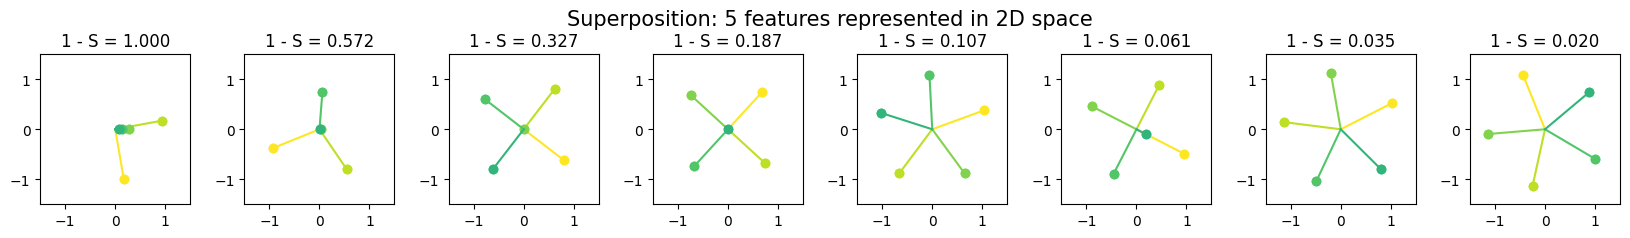

In [3]:
utils.plot_features_in_2d(
    model.W,
    colors=model.importance,
    title=f"Superposition: {cfg.n_features} features represented in 2D space",
    subplot_titles=[f"1 - S = {i:.3f}" for i in feature_probability.squeeze()],
)

In [4]:
@dataclass
class ToySAEConfig:
    n_inst: int
    d_in: int
    d_sae: int
    sparsity_coeff: float = 0.2
    weight_normalize_eps: float = 1e-8
    tied_weights: bool = False
    ste_epsilon: float = 0.01


class ToySAE(nn.Module):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]

    def __init__(self, cfg: ToySAEConfig, model: ToyModel) -> None:
        super(ToySAE, self).__init__()

        assert cfg.d_in == model.cfg.d_hidden, "Model's hidden dim doesn't match SAE input dim"
        self.cfg = cfg
        self.model = model.requires_grad_(False)
        self.model.W.data[1:] = self.model.W.data[0]
        self.model.b_final.data[1:] = self.model.b_final.data[0]

        self.W_enc = nn.Parameter(nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_in, cfg.d_sae))))
        self._W_dec = (
            None
            if self.cfg.tied_weights
            else nn.Parameter(nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_sae, cfg.d_in))))
        )
        self.b_enc = nn.Parameter(t.zeros(cfg.n_inst, cfg.d_sae))
        self.b_dec = nn.Parameter(t.zeros(cfg.n_inst, cfg.d_in))

        self.to(device)

    @property
    def W_dec(self) -> Float[Tensor, "inst d_sae d_in"]:
        return self._W_dec if self._W_dec is not None else self.W_enc.transpose(-1, -2)


    # notice how this is normalized right now. We remove this below
    @property
    def W_dec_normalized(self) -> Float[Tensor, "inst d_sae d_in"]:
        """Returns decoder weights, normalized over the autoencoder input dimension."""
        return self.W_dec # no constrained normalization occurring
    
    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch inst d_in"]:
        """
        Generates a batch of hidden activations from our model.
        """
        batch = self.model.generate_batch(batch_size) 
        return einops.einsum(batch, self.model.W, 'b i f, i h f -> b i h')


    
    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, "batch inst"],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Forward pass on the autoencoder.

        Args:
            h: hidden layer activations of model

        Returns:
            loss_dict:       dict of different loss terms, each having shape (batch_size, n_inst)
            loss:            total loss (i.e. sum over terms of loss dict), same shape as loss values
            acts_post:       autoencoder latent activations, after applying ReLU
            h_reconstructed: reconstructed autoencoder input
        """

        # z = relu(W_enc(h - b_dec) + b_enc)
        centered = h - self.b_dec
        proj = einops.einsum(self.W_enc, centered, 'inst d_in d_sae ,batch inst d_in -> batch inst d_sae') + self.b_enc
        acts_post = F.relu(proj)

        # h' = (W_dec * z) + b_dec
        h_reconstructed = einops.einsum(self.W_dec_normalized, acts_post, 'inst d_sae d_in, batch inst d_sae -> batch inst d_in') + self.b_dec

        # compute reconstruction loss: 
        L_reconstruction = einops.reduce((h - h_reconstructed)**2,'batch inst d_in -> batch inst', reduction='mean')

        # compute sparsity loss with modifications described in scaling monosemanticity
        sum_of_squares = einops.reduce(self.W_dec_normalized**2, 'inst d_sae d_in -> inst d_sae', reduction='sum') # get sum of squares
        l2_norm = torch.sqrt(sum_of_squares) # l2 norm = sqrt(a^2 + b^2 .... n^2)

        loss_term = acts_post * l2_norm * self.cfg.sparsity_coeff # (batch, inst, d_sae) * (inst, d_sae). this will automatically broadcast
        
        # loss_term = acts_post * self.W_dec_normalized.norm(dim=-1, keepdim=True) # now we're using the unconstrained L2 norm as a penalty to multiply our activations by
        L_sparsity = einops.reduce(loss_term, 'batch inst d_sae -> batch inst', reduction='sum')

        # form return parameters
        loss_dict = {
            "L_reconstruction": L_reconstruction,
            "L_sparsity": L_sparsity
        }
        loss = L_sparsity + L_reconstruction
        return loss_dict, loss, acts_post, h_reconstructed

    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 10_000,
        log_freq: int = 100,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
        resample_method: Literal["simple", "advanced", None] = None,
        resample_freq: int = 2500,
        resample_window: int = 500,
        resample_scale: float = 0.5,
        hidden_sample_size: int = 256,
    ) -> list[dict[str, Any]]:
        """
        Optimizes the autoencoder using the given hyperparameters.

        Args:
            model:              we reconstruct features from model's hidden activations
            batch_size:         size of batches we pass through model & train autoencoder on
            steps:              number of optimization steps
            log_freq:           number of optimization steps between logging
            lr:                 learning rate
            lr_scale:           learning rate scaling function
            resample_method:    method for resampling dead latents
            resample_freq:      number of optimization steps between resampling dead latents
            resample_window:    number of steps needed for us to classify a neuron as dead
            resample_scale:     scale factor for resampled neurons
            hidden_sample_size: size of hidden value sample we add to the logs (for visualization)

        Returns:
            data_log:           dictionary containing data we'll use for visualization
        """
        assert resample_window <= resample_freq

        optimizer = t.optim.Adam(self.parameters(), lr=lr)  # betas=(0.0, 0.999)
        frac_active_list = []
        progress_bar = tqdm(range(steps))

        # Create lists of dicts to store data we'll eventually be plotting
        data_log = []

        for step in progress_bar:
            # Resample dead latents
            if (resample_method is not None) and ((step + 1) % resample_freq == 0):
                frac_active_in_window = t.stack(frac_active_list[-resample_window:], dim=0)
                if resample_method == "simple":
                    self.resample_simple(frac_active_in_window, resample_scale)
                elif resample_method == "advanced":
                    self.resample_advanced(frac_active_in_window, resample_scale, batch_size)

            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Get a batch of hidden activations from the model
            with t.inference_mode():
                h = self.generate_batch(batch_size)

            # Optimize
            loss_dict, loss, acts, _ = self.forward(h)
            loss.mean(0).sum().backward()
            optimizer.step()
            optimizer.zero_grad()

            # Normalize decoder weights by modifying them directly (if not using tied weights)
            if not self.cfg.tied_weights:
                self.W_dec.data = self.W_dec_normalized.data

            # Calculate the mean sparsities over batch dim for each feature
            frac_active = (acts.abs() > 1e-8).float().mean(0)
            frac_active_list.append(frac_active)

            # Display progress bar, and log a bunch of values for creating plots / animations
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(
                    lr=step_lr,
                    loss=loss.mean(0).sum().item(),
                    frac_active=frac_active.mean().item(),
                    **{k: v.mean(0).sum().item() for k, v in loss_dict.items()},  # type: ignore
                )
                with t.inference_mode():
                    loss_dict, loss, acts, h_r = self.forward(
                        h := self.generate_batch(hidden_sample_size)
                    )
                data_log.append(
                    {
                        "steps": step,
                        "frac_active": (acts.abs() > 1e-8).float().mean(0).detach().cpu(),
                        "loss": loss.detach().cpu(),
                        "h": h.detach().cpu(),
                        "h_r": h_r.detach().cpu(),
                        **{name: param.detach().cpu() for name, param in self.named_parameters()},
                        **{name: loss_term.detach().cpu() for name, loss_term in loss_dict.items()},
                    }
                )

        return data_log

    @t.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        """
        Resamples dead latents, by modifying the model's weights and biases inplace.

        Resampling method is:
            - For each dead neuron, generate a random vector of size (d_in,), and normalize these vecs
            - Set new values of W_dec and W_enc to be these normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

    @t.no_grad()
    def resample_advanced( 
        self: nn.Module,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:

        """
        Resamples latents that have been dead for 'dead_feature_window' steps, according to `frac_active`.

        Resampling method is:
            - Compute the L2 reconstruction loss produced from the hidden state vecs `h`
            - Randomly choose values of `h` with probability proportional to their reconstruction loss
            - Set new values of W_dec & W_enc to be these centered & normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron

        Returns colors and titles (useful for creating the animation: resampled neurons appear in red).
        """
        print(f"using resample advanced")
        h = self.generate_batch(batch_size)
        l2_loss = self.forward(h)[0]["L_reconstruction"]

        for instance in range(self.cfg.n_inst):
            # Find the dead latents in this instance. If all latents are alive, continue
            is_dead = (frac_active_in_window[:, instance] < 1e-8).all(dim=0)
            dead_latents = t.nonzero(is_dead).squeeze(-1)
            n_dead = dead_latents.numel()
            if n_dead == 0:
                continue  # If we have no dead features, then we don't need to resample

            # Compute L2 loss for each element in the batch
            l2_loss_instance = l2_loss[:, instance]  # [batch_size]
            if l2_loss_instance.max() < 1e-6:
                continue  # If we have zero reconstruction loss, we don't need to resample

            # Draw `d_sae` samples from [0, 1, ..., batch_size-1], with probabilities proportional to
            # values of l2_loss
            distn = Categorical(probs=l2_loss_instance.pow(2) / l2_loss_instance.pow(2).sum())
            replacement_indices = distn.sample((n_dead,))  # type: ignore

            # Index into the batch of hidden activations to get our replacement values
            replacement_values = (h - self.b_dec)[replacement_indices, instance]  # [n_dead d_in]
            replacement_values_normalized = replacement_values / (
                replacement_values.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps
            )

            # Get the norm of alive neurons (or 1.0 if there are no alive neurons)
            W_enc_norm_alive_mean = (
                self.W_enc[instance, :, ~is_dead].norm(dim=0).mean().item() if (~is_dead).any() else 1.0
            )

            # Lastly, set the new weights & biases (W_dec is normalized, W_enc needs specific scaling,
            # b_enc is zero)
            self.W_dec.data[instance, dead_latents, :] = replacement_values_normalized
            self.W_enc.data[instance, :, dead_latents] = (
                replacement_values_normalized.T * W_enc_norm_alive_mean * resample_scale
            )
            self.b_enc.data[instance, dead_latents] = 0.0

In [10]:
# train SAE
d_hidden = d_in = 2
n_features = d_sae = 5
n_inst = 16
sae = ToySAE(cfg=ToySAEConfig(n_inst=n_inst, d_in=d_in, d_sae=d_sae), model=model)

# h = sae.generate_batch(512)
# loss_dict, loss, acts_post, h_reconstructed = sae.forward(h)
data_log = sae.optimize(steps=20_000, resample_method="advanced")

 13%|█▎        | 2505/20000 [00:38<05:13, 55.76it/s, L_reconstruction=0.248, L_sparsity=0.374, frac_active=0.146, loss=0.622, lr=0.001] 

using resample advanced


 25%|██▌       | 5009/20000 [01:13<03:23, 73.80it/s, L_reconstruction=0.181, L_sparsity=0.346, frac_active=0.102, loss=0.527, lr=0.001] 

using resample advanced


 38%|███▊      | 7507/20000 [01:49<03:00, 69.28it/s, L_reconstruction=0.175, L_sparsity=0.358, frac_active=0.11, loss=0.532, lr=0.001]  

...

using resample advanced


 88%|████████▊ | 17508/20000 [04:17<00:34, 73.03it/s, L_reconstruction=0.177, L_sparsity=0.337, frac_active=0.118, loss=0.514, lr=0.001]

using resample advanced


100%|██████████| 20000/20000 [04:57<00:00, 67.17it/s, L_reconstruction=0.183, L_sparsity=0.325, frac_active=0.116, loss=0.507, lr=0.001]


using resample advanced


In [11]:
utils.frac_active_line_plot(
    frac_active=t.stack([data["frac_active"] for data in data_log]),
    title="Probability of sae features being active during training",
    avg_window=20,
)

### Now let's modify our code and make a jumpRELU method!


We're going to start by implementing custom `jumprelu` and `heaviside` functions. PyTorch provides a helpful way to create custom functions with different behaviours in their forward and backward passes. For example, below is one with forward behaviour $f(x) = x^n$, and backward behaviour $f'(x) = nx^{n-1}$.

Note, we need to return `n * (input ** (n - 1)) * grad_output` from our backward function, rather than just `n * (input ** (n - 1))`, since we're actually computing $\frac{dL}{dx} = \frac{dL}{df(x)} \times f'(x)$ via the chain rule (where $x$ is `input` and $\frac{dL}{df(x)}$ is `grad_output`) - if you're confused here, you might want to revisit the ARENA material from the fundamentals chapter, on building your own backprop.

Also note that the `backward` function actually returns a tuple, which consists of all gradients wrt each of the `forward` arguments in the order they were in for `forward` (this includes the integer `n`). We return `None` since we don't need to track gradients wrt this variable.


In [ ]:
class CustomFunction(t.autograd.Function):
    @staticmethod
    def forward(ctx: Any, input: Tensor, n: int) -> Tensor:
        # Save any necessary information for backward pass
        ctx.save_for_backward(input)
        ctx.n = n  # Save n as it will be needed in the backward pass
        # Compute the output
        return input**n

    @staticmethod
    def backward(ctx: Any, grad_output: Tensor) -> tuple[Tensor, None]:
        # Retrieve saved tensors and n
        (input,) = ctx.saved_tensors
        n = ctx.n
        # Return gradient for input and None for n (as it's not a Tensor)
        return n * (input ** (n - 1)) * grad_output, None


# Test our function, and its gradient
input = t.tensor(3.0, requires_grad=True)
output = CustomFunction.apply(input, 2)
output.backward()

t.testing.assert_close(output, t.tensor(9.0))
t.testing.assert_close(input.grad, t.tensor(6.0))


Now let's use this example to come up with our Heaviside and JumpRELU functions. Note that both take 2 tensor inputs $z$ and $\theta$ as well as one float $\epsilon$. We're using the following conventions for our Heaviside function:

$$
\begin{aligned}
H(z, \theta; \epsilon) & := \boldsymbol{\mathbb{1}}[z - \theta > 0] \\
\frac{ð}{ð z} H(z, \theta; \epsilon) & := 0 \\
\frac{ð}{ð \theta} H(z, \theta; \epsilon) & := -\frac{1}{\epsilon} K\left(\frac{z-\theta}{\epsilon}\right) \\
\end{aligned}
$$

and for our JumpReLU:

$$
\begin{aligned}
\operatorname{JumpReLU}(z, \theta; \epsilon) & := z \cdot \boldsymbol{\mathbb{1}}[z - \theta > 0] \\
\frac{ð}{ð z} \operatorname{JumpReLU}(z, \theta; \epsilon) & := \boldsymbol{\mathbb{1}}[z - \theta > 0] \\
\frac{ð}{ð \theta} \operatorname{JumpReLU}(z, \theta; \epsilon) & :=-\frac{\theta}{\epsilon} K\left(\frac{z-\theta}{\epsilon}\right)
\end{aligned}
$$

where $K(x) = \boldsymbol{\mathbb{1}}\left[|x| < \frac{1}{2}\right]$ is the rectangle kernel function.

In both cases we use the STE estimator for derivatives wrt $\theta$, but ignore STE estimates for $z$, i.e. we differentiate wrt $z$ pretending that $\frac{ð}{ð z} \boldsymbol{\mathbb{1}}[z - \theta > 0] = 0$. This is so that our parameter $\theta$ is the only one that implements the thresholding behaviour. Essentially, you can think of the other parameters being updated by gradient descent under the assumption that the output is a locally continuous function of those parameters.


In [ ]:
def rectangle(x: Tensor, width: float = 1.0) -> Tensor:
    """
    Returns the rectangle function value, i.e. K(x) = 1[|x| < width/2], as a float.
    """
    return (x.abs() < width / 2).float()


class Heaviside(t.autograd.Function):
    """
    Implementation of the Heaviside step function, using straight through estimators for the deriv.

        forward:
            H(z,θ,ε) = 1[z > θ]

        backward:
            dH/dz := None
            dH/dθ := -1/ε * K(z/ε)

            where K is the rectangle kernel function with width 1, centered at 0: K(u) = 1[|u| < 1/2]
    """

    @staticmethod
    def forward(ctx: Any, z: Tensor, theta: Tensor, eps: float) -> Tensor:
        # Save any necessary information for backward pass
        ctx.save_for_backward(z, theta)
        ctx.eps = eps
        # Compute the output
        return (z > theta).float()

    @staticmethod
    def backward(ctx: Any, grad_output: Tensor) -> tuple[Tensor, Tensor, None]:
        # Retrieve saved tensors & values
        (z, theta) = ctx.saved_tensors
        eps = ctx.eps
        # Compute gradient of the loss with respect to z (no STE) and theta (using STE)
        grad_z = 0.0 * grad_output
        grad_theta = -(1.0 / eps) * rectangle((z - theta) / eps) * grad_output
        grad_theta_agg = grad_theta.sum(dim=0)  # note, sum over batch dim isn't strictly necessary

        return grad_z, grad_theta_agg, None


# Test our Heaviside function, and its pseudo-gradient
z = t.tensor([[1.0, 1.4, 1.6, 2.0]], requires_grad=True)
theta = t.tensor([1.5, 1.5, 1.5, 1.5], requires_grad=True)
eps = 0.5
output = Heaviside.apply(z, theta, eps)
output.backward(t.ones_like(output))  # equiv to backprop on each elem of z independently

# Test values
t.testing.assert_close(output, t.tensor([[0.0, 0.0, 1.0, 1.0]]))  # expect H(θ,z,ε) = 1[z > θ]
t.testing.assert_close(
    theta.grad, t.tensor([0.0, -2.0, -2.0, 0.0])
)  # expect dH/dθ = -1/ε * K((z-θ)/ε)
t.testing.assert_close(z.grad, t.tensor([[0.0, 0.0, 0.0, 0.0]]))  # expect dH/dz = zero

# Test handling of batch dimension
theta.grad = None
output_stacked = Heaviside.apply(t.concat([z, z]), theta, eps)
output_stacked.backward(t.ones_like(output_stacked))
t.testing.assert_close(theta.grad, 2 * t.tensor([0.0, -2.0, -2.0, 0.0]))

print("All tests for `Heaviside` passed!")

Brief explanation of where we're getting the expected values for the Heaviside function

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/jumprelu-3b.png" width="700">


### Now for JumpReLU

Here is a summary of the changes we're making to our SAE class

- Add the parameter `log_theta`, which has shape `(n_instances, d_sae)` and produces your vectors `theta` which are used in your JumpReLU / Heaviside functions.
    - We use `log_theta` rather than `theta` because our threshold values should always be positive.
    - Both when initializing and resampling, we recommend taking `theta = 0.1` rather than the paper's value of `0.001` (this is because small values take a long time to increase, thanks to the small gradients in the `log` function). You'll need to convert these values to log-space when setting `log_theta`.
- SAE hidden values now use the JumpReLU activation function rather than standard ReLU, i.e. the i-th hidden value is $\operatorname{JumpReLU}_\theta(\pi_i(x))$, where $\pi_i(x) = (W_{enc}x + b_{enc})_i$ are the pre-JumpReLU activations.
    - In the DeepMind appendix, they suggest passing $\operatorname{ReLU}(\pi_i(x))$ rather than $\pi_i(x)$ into the ReLU and JumpReLU functions (this is so that negative values of $\pi_i(x)$ don't affect the gradient, in edge-case situations where $\theta_i$ has gotten small enough that we can have $0 > \pi_i(x) > \theta_i - \epsilon/2$). We recommend this too.
- The sparsity loss term is no longer the L1 norm, instead it's $\lambda \|\mathbf{f}(\mathbf{x})\|_0 = \sum_{i=1}^{d_{\text{sae}}} H(\pi_i(x) - \theta_i)$, where $\lambda$ is the sparsity coefficient.
    - We recommend starting with a value of `0.1` for the sparsity coefficient; this is given to you in the example code below.
    - Note that we still sum this L0 penalty term over `d_sae` rather than averaging it, for the same reasons as we summed over `d_sae` for our L1 penalty term.
- We will use a default value of `ste_epsilon=0.01` for the STE, rather than the DeepMind paper's value of `0.001`

In [ ]:
THETA_INIT = 0.1


class JumpReLUToySAE(ToySAE):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]
    log_theta: Float[Tensor, "inst d_sae"]
    def __init__(self, cfg: ToySAEConfig, model: ToyModel):
        super(ToySAE, self).__init__()

        assert cfg.d_in == model.cfg.d_hidden, "ToyModel's hidden dim doesn't match SAE input dim"
        self.cfg = cfg
        self.model = model.requires_grad_(False)
        self.model.W.data[1:] = self.model.W.data[0]
        self.model.b_final.data[1:] = self.model.b_final.data[0]

        self._W_dec = (
            None
            if self.cfg.tied_weights
            else nn.Parameter(nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_sae, cfg.d_in))))
        )
        self.b_dec = nn.Parameter(t.zeros(cfg.n_inst, cfg.d_in))

        self.W_enc = nn.Parameter(
            nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_in, cfg.d_sae)))
        )
        self.b_enc = nn.Parameter(t.zeros(cfg.n_inst, cfg.d_sae))
        self.log_theta = nn.Parameter(t.full((cfg.n_inst, cfg.d_sae), t.log(t.tensor(THETA_INIT))))

        self.to(device)

    @property
    def theta(self) -> Float[Tensor, "inst d_sae"]:
        return self.log_theta.exp()

    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, ""],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Same as previous forward function, but allows for gated case as well (in which case we have different
        functional form, as well as a new term "L_aux" in the loss dict).
        """
        h_cent = h - self.b_dec

        acts_pre = (
            einops.einsum(
                h_cent, self.W_enc, "batch inst d_in, inst d_in d_sae -> batch inst d_sae"
            )
            + self.b_enc
        )
        # print(self.theta.mean(), self.theta.std(), self.theta.min(), self.theta.max())
        acts_relu = F.relu(acts_pre)
        acts_post = JumpReLU.apply(acts_relu, self.theta, self.cfg.ste_epsilon)

        h_reconstructed = (
            einops.einsum(
                acts_post, self.W_dec, "batch inst d_sae, inst d_sae d_in -> batch inst d_in"
            )
            + self.b_dec
        )

        loss_dict = {
            "L_reconstruction": (h_reconstructed - h).pow(2).mean(-1),
            "L_sparsity": Heaviside.apply(acts_relu, self.theta, self.cfg.ste_epsilon).sum(-1),
        }

        loss = loss_dict["L_reconstruction"] + self.cfg.sparsity_coeff * loss_dict["L_sparsity"]

        return loss_dict, loss, acts_post, h_reconstructed

    @t.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        dead_latents_mask = (frac_active_in_window < 1e-8).all(dim=0)  # [instances d_sae]
        n_dead = int(dead_latents_mask.int().sum().item())

        replacement_values = t.randn((n_dead, self.cfg.d_in), device=self.W_enc.device)
        replacement_values_normed = replacement_values / (
            replacement_values.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps
        )

        # New names for weights & biases to resample
        self.W_enc.data.transpose(-1, -2)[dead_latents_mask] = (
            resample_scale * replacement_values_normed
        )
        self.W_dec.data[dead_latents_mask] = replacement_values_normed
        self.b_enc.data[dead_latents_mask] = 0.0
        self.log_theta.data[dead_latents_mask] = t.log(t.tensor(THETA_INIT))

    @t.no_grad()
    def resample_advanced(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:
        h = self.generate_batch(batch_size)
        l2_loss = self.forward(h)[0]["L_reconstruction"]

        for instance in range(self.cfg.n_inst):
            is_dead = (frac_active_in_window[:, instance] < 1e-8).all(dim=0)
            dead_latents = t.nonzero(is_dead).squeeze(-1)
            n_dead = dead_latents.numel()
            if n_dead == 0:
                continue

            l2_loss_instance = l2_loss[:, instance]  # [batch_size]
            if l2_loss_instance.max() < 1e-6:
                continue

            distn = Categorical(probs=l2_loss_instance.pow(2) / l2_loss_instance.pow(2).sum())
            replacement_indices = distn.sample((n_dead,))  # type: ignore

            replacement_values = (h - self.b_dec)[replacement_indices, instance]  # [n_dead d_in]
            replacement_values_normalized = replacement_values / (
                replacement_values.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps
            )

            W_enc_norm_alive_mean = (
                self.W_enc[instance, :, ~is_dead].norm(dim=0).mean().item()
                if (~is_dead).any()
                else 1.0
            )

            # New names for weights & biases to resample
            self.b_enc.data[instance, dead_latents] = 0.0
            self.log_theta.data[instance, dead_latents] = t.log(t.tensor(THETA_INIT))
            self.W_dec.data[instance, dead_latents, :] = replacement_values_normalized
            self.W_enc.data[instance, :, dead_latents] = (
                replacement_values_normalized.T * W_enc_norm_alive_mean * resample_scale
            )


jumprelu_sae = JumpReLUToySAE(
    cfg=ToySAEConfig(
        n_inst=n_inst, d_in=d_in, d_sae=d_sae, tied_weights=True, sparsity_coeff=0.1
    ),
    model=model,
)
jumprelu_data_log = jumprelu_sae.optimize(
    steps=20_000, resample_method="advanced"
)  # batch_size=4096?

# Animate the best instances, ranked according to average loss near the end of training
n_inst_to_plot = 4
n_batches_for_eval = 10
avg_loss = t.concat([d["loss"] for d in jumprelu_data_log[-n_batches_for_eval:]]).mean(0)
best_instances = avg_loss.topk(n_inst_to_plot, largest=False).indices.tolist()

utils.animate_features_in_2d(
    jumprelu_data_log,
    rows=["W_enc", "h", "h_r"],
    instances=best_instances,
    filename=str(section_dir / "animation-training-jumprelu.html"),
    color_resampled_latents=True,
    title="JumpReLU SAE on toy model",
)

# Replicate figure 15 for jumprelu SAE (should get same results as for gated)
replicate_figure_15(
    [
        ("standard", resampling_sae, resampling_data_log),
        # ("gated", gated_sae, gated_data_log), # you can comment this back in, to compare all 3!
        ("jumprelu", jumprelu_sae, jumprelu_data_log),
    ]
)

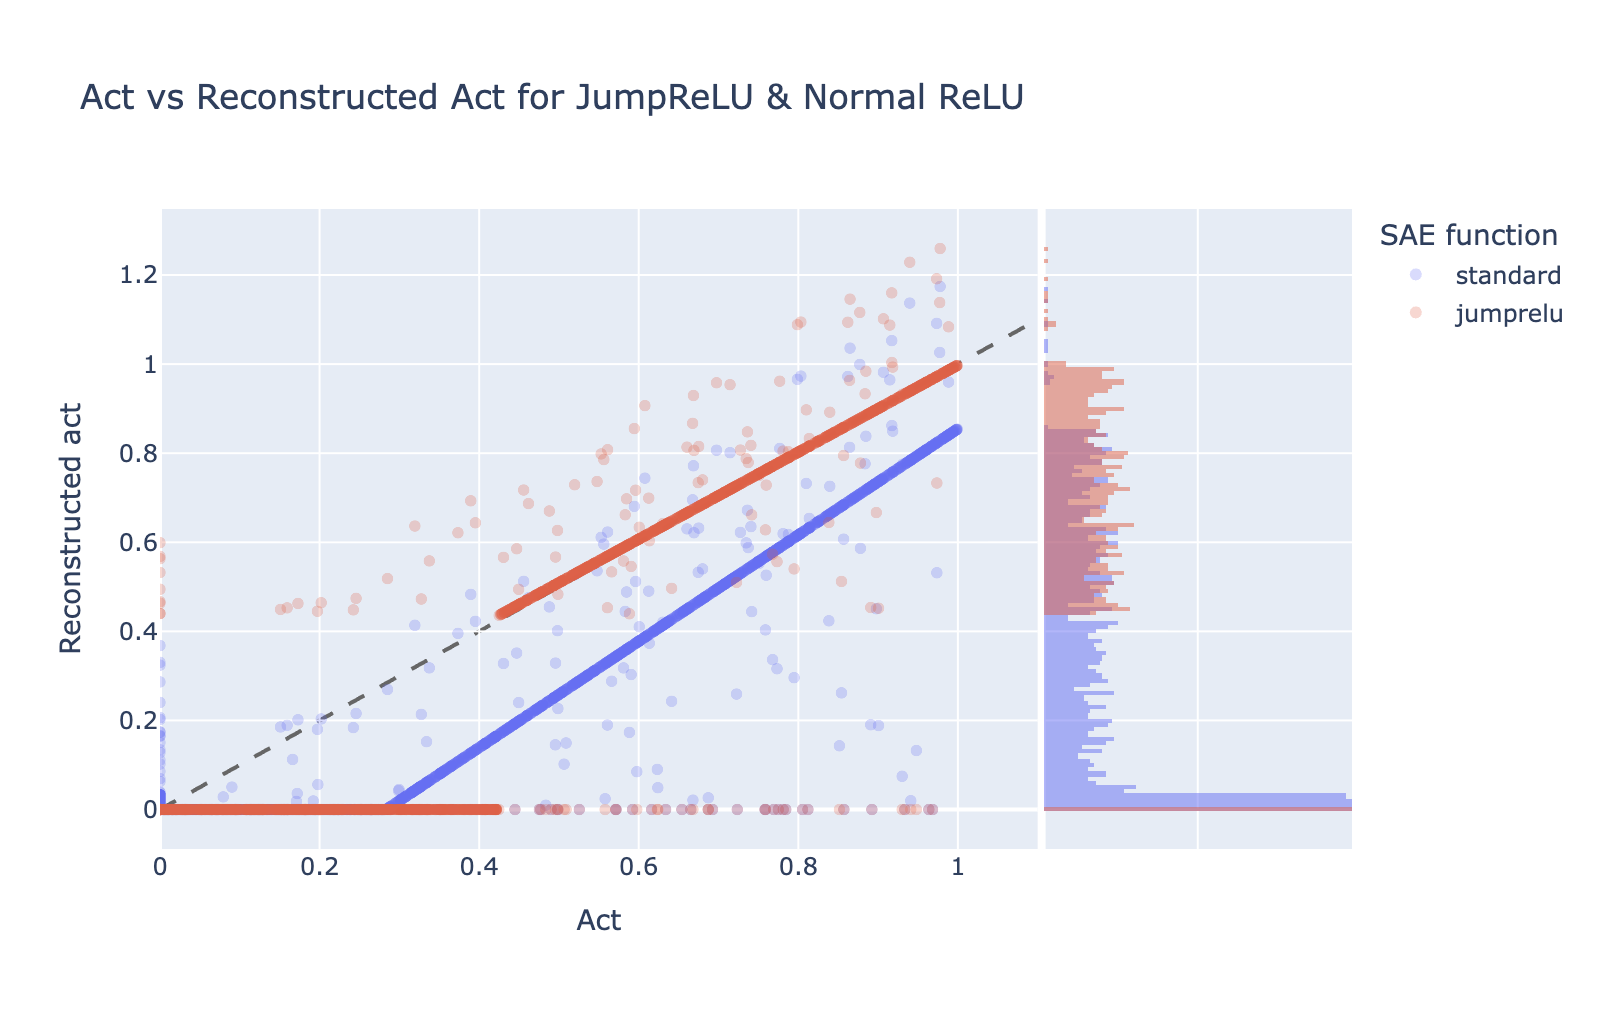

Notice the improvement! Our JumpReLU model has consistently higher reconstruction activaitons (the x-axis of this image gives the ground truth activations, while the y axis gives the reconstructed activations. zero reconstruction loss corresponds to the line $y=x$)

## Circuit Tracing

Core problem: We have a neural architecture that can extract interpretable features, but how can we design a neural architecture to extract interpretable computations done on those features? 


 Oh i see, so the idea is "SAE's: take residual stream as input, learn how to produce residual stream as output. Transcoders: take residual stream as input, learn how to produce MLP layer activations -- the thing that would be added back to the residual stream -- as an output
